# Getting Started

## Overview
This semester, all homeworks will be conducted through Google Colab notebooks. All code for the homework assignment will be written and run in this notebook. Running in Colab will automatically provide a GPU, but you may also run this notebook locally by following [these instructions](https://research.google.com/colaboratory/local-runtimes.html) if you wish to use your own GPU.

You will save images in the notebooks to use and fill out a given LaTeX template which will be submitted to Gradescope, along with your notebook code.

## Using Colab
On the left-hand side, you can click the different icons to see a Table of Contents of the assignment, as well as local files accessible through the notebook.

Make sure to go to **Runtime -> Change runtime type** and select **GPU** as the hardware accelerator. This allows you to use a GPU. Run the cells below to get started on the assignment. Note that a session is open for a maximum of 12 hours, and using too much GPU compute may result in restricted access for a short period of time. Please start the homework early so you have ample time to work.

**If you loaded this notebook from clicking "Open in Colab" from github, you will need to save it to your own Google Drive to keep your work.**

## General Tips
In each homework problem, you will implement various autoencoder models and run them on two datasets (dataset 1 and dataset 2). The expected outputs for dataset 1 are already provided to help as a sanity check.

Feel free to print whatever output (e.g. debugging code, training code, etc) you want, as the graded submission will be the submitted pdf with images.

After you complete the assignment, download all of the image outputted in the results/ folder and upload them to the figure folder in the given latex template.

Run the cells below to download and load up the starter code. It may take longer to run since we are using larger datasets.

In [ ]:
!if [ -d deepul ]; then rm -Rf deepul; fi
!git clone https://github.com/rll/deepul.git
!curl "https://drive.usercontent.google.com/download?id=1lWjGICwgzgcBDejo9S5g69hLAf0O3lGF&confirm=xxx" -o hw2_data.zip
!unzip -qq hw2_data.zip -d deepul/homeworks/hw2/data
!pip install ./deepul
from deepul.hw2_helper import *

Cloning into 'deepul'...
remote: Enumerating objects: 254, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 254 (delta 46), reused 32 (delta 32), pack-reused 182
Receiving objects: 100% (254/254), 94.70 MiB | 17.48 MiB/s, done.
Resolving deltas: 100% (95/95), done.
Updating files: 100% (149/149), done.
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  231M  100  231M    0     0  54.1M      0  0:00:04  0:00:04 --:--:-- 54.1M
Processing ./deepul
  Preparing metadata (setup.py) ... done
  Created wheel for deepul: filename=deepul-0.1.0-py3-none-any.whl size=22738 sha256=c7a2b1e8a8aa4af48ced8764083c7c19df06a15ee00e2c14a79a9bc473cd3855
  Stored in directory: /tmp/pip-ephem-wheel-cache-zdv9k6ds/wheels/89/4d/b7/d666c1fdc2a51554c762f2cfe90dad1098871e7fea5c53eed4
Successfully built deepul


# Question 1: VAEs on 2D Data [20pts]
In this question, you will train a simple VAE on 2D data, and look at situations in which latents are being used or not being used (i.e. when posterior collapse occurs)

## Part (a) Data from a Full Covariance Gaussian [10 pts]
In this part, we train a VAE on data generated from a Gaussian with a full covariance matrix. Execute the cell below to visualize the datasets.

Dataset 1


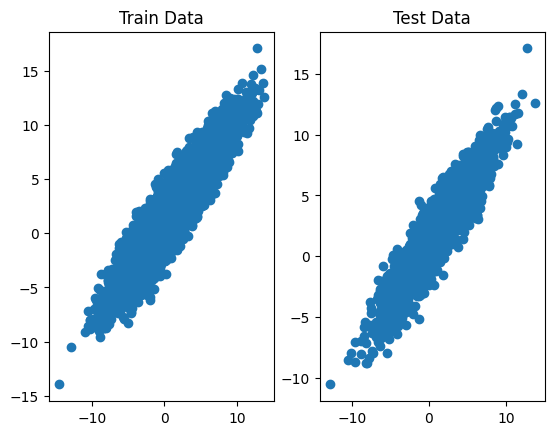

Dataset 2


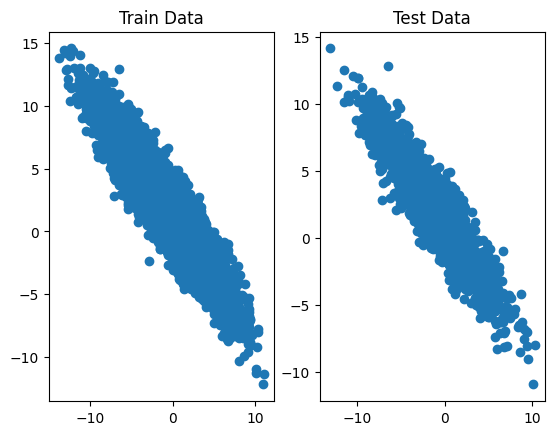

In [ ]:
visualize_q1_data('a', 1)
visualize_q1_data('a', 2)

Consruct and train a VAE with the following characteristics
*   2D latent variables $z$ with a standard normal prior, $p(z) = N(0, I)$
*   An approximate posterior $q_\theta(z|x) = N(z; \mu_\theta(x), \Sigma_\theta(x))$, where $\mu_\theta(x)$ is the mean vector, and $\Sigma_\theta(x)$ is a diagonal covariance matrix
*   A decoder $p(x|z) = N(x; \mu_\phi(z), \Sigma_\phi(z))$, where $\mu_\phi(z)$ is the mean vector, and $\Sigma_\phi(z)$ is a diagonal covariance matrix

**You will provide the following deliverables**


1.   Over the course of training, record the average full negative ELBO, reconstruction loss $E_xE_{z\sim q(z|x)}[-p(x|z)]$, and KL term $E_x[D_{KL}(q(z|x)||p(z))]$ of the training data (per minibatch) and test data (for your entire test set). Code is provided that automatically plots the training curves.
2.   Report the final test set performance of your final model
3. Samples of your trained VAE with ($z\sim p(z), x\sim N(x;\mu_\phi(z),\Sigma_\phi(z))$) and without ($z\sim p(z), x = \mu_\phi(z)$) decoder noise




### Solution
Fill out the function below and return the neccessary arguments. Feel free to create more cells if need be

### Results
Once you've finished `q1_a`, execute the cells below to visualize and save your results.

In [ ]:
q1_save_results('a', 1, q1)

In [ ]:
q1_save_results('a', 2, q1)

## Part (b) Data from a Diagonal Gaussian [10pts]
In this part, we use your code from the previous part to train a VAE on data generated from a diagonal gaussian. Execute the cell below to visualize the datasets (note that they may look the same, but notice the axes)

In [ ]:
visualize_q1_data('b', 1)
visualize_q1_data('b', 2)

### Results
Execute the cells below to visualize and save your results.

In [ ]:
q1_save_results('b', 1, q1)

In [ ]:
q1_save_results('b', 2, q1)

### Reflection
Compare the sampled xs with and without latents in parts (a) and (b). For which datasets are the latents being used? Why is this happening (i.e. why are the latents being ignored in some cases)? **Write your answer (1-2 sentences) in the given latex template**

# Question 2: VAEs on Images [40pts]
In this question, you will train different VAE models on image datasets. Execute the cell below to visualize the two datasets (colored shapes, and [SVHN](http://ufldl.stanford.edu/housenumbers/)).

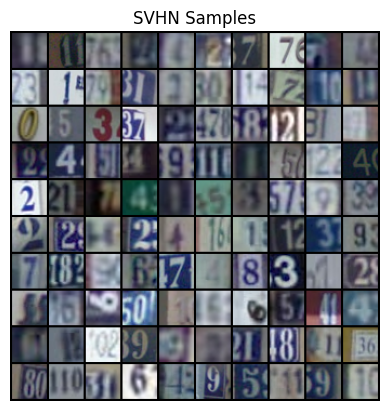

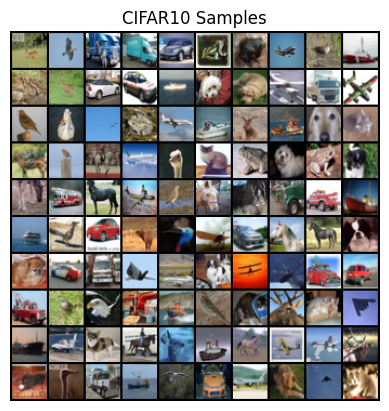

In [ ]:
visualize_svhn()
visualize_cifar10()

## Part (a) VAE [20pts]
In this part, implement a standard VAE with the following characteristics:

*   16-dim latent variables $z$ with standard normal prior $p(z) = N(0,I)$
*   An approximate posterior $q_\theta(z|x) = N(z; \mu_\theta(x), \Sigma_\theta(x))$, where $\mu_\theta(x)$ is the mean vector, and $\Sigma_\theta(x)$ is a diagonal covariance matrix
*   A decoder $p(x|z) = N(x; \mu_\phi(z), I)$, where $\mu_\phi(z)$ is the mean vector. (We are not learning the covariance of the decoder)

You can play around with different architectures and try for better results, but the following encoder / decoder architecture below suffices (Note that image input is always $32\times 32$.
```
conv2d(in_channels, out_channels, kernel_size, stride, padding)
transpose_conv2d(in_channels, out_channels, kernel_size, stride, padding)
linear(in_dim, out_dim)

Encoder
    conv2d(3, 32, 3, 1, 1)
    relu()
    conv2d(32, 64, 3, 2, 1) # 16 x 16
    relu()
    conv2d(64, 128, 3, 2, 1) # 8 x 8
    relu()
    conv2d(128, 256, 3, 2, 1) # 4 x 4
    relu()
    flatten() # 16
    linear(4 * 4 * 256, 2 * latent_dim)

Decoder
    linear(latent_dim, 4 * 4 * 128)
    relu()
    reshape(4, 4, 128)
    transpose_conv2d(128, 128, 4, 2, 1) # 8 x 8
    relu()
    transpose_conv2d(128, 64, 4, 2, 1) # 16 x 16
    relu()
    transpose_conv2d(64, 32, 4, 2, 1) # 32 x 32
    relu()
    conv2d(32, 3, 3, 1, 1)
```

You may find the following training tips helpful
*   When computing reconstruction loss and KL loss, average over the batch dimension and **sum** over the feature dimension
*   When computing reconstruction loss, it suffices to just compute MSE between the reconstructed $x$ and true $x$
*   Use batch size 128, learning rate $10^{-3}$, and an Adam optimizer




**You will provide the following deliverables**


1.   Over the course of training, record the average full negative ELBO, reconstruction loss, and KL term of the training data (per minibatch) and test data (for your entire test set). Code is provided that automatically plots the training curves.
2.   Report the final test set performance of your final model
3. 100 samples from your trained VAE
4. 50 real-image / reconstruction pairs (for some $x$, encode and then decode)
5. 10 interpolations of 10 images from your trained VAE (100 images total)



### Solution
Fill out the function below and return the neccessary arguments. Feel free to create more cells if need be

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = torch.float32

class VAE_Encoder(nn.Module):
    def __init__(self, in_shape):
        super().__init__()
        N, C, H, W = in_shape
        self.latent_dim = 16
        self.out_linear = nn.Linear(4*4*256, 2*self.latent_dim)
        self.q = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),  # 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1),  # 8x8
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, 2, 1),  # 4x4
            nn.ReLU())

    def forward(self, x):
        out = self.q(x)
        out = torch.flatten(out, start_dim=1, end_dim=-1)
        out = self.out_linear(out)
        return out

class VAE_Decoder(nn.Module):
    def __init__(self, in_shape):
        super().__init__()
        N, C, H, W = in_shape
        self.latent_dim = 16
        self.p = nn.Sequential( # start with 4x4
# in_channels, out_channels, kernel_size, stride=1, padding=0, output_padding=0
            nn.ConvTranspose2d(128, 128, 4, 2, 1), # 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), # 32x32
            nn.ReLU(),
            nn.Conv2d(32, 3, 3, 1, 1))

        self.in_linear = nn.Linear(self.latent_dim, 4*4*128)

    def forward(self, x):
        out = self.in_linear(x)
        out = F.relu(out)
        N, _ = out.shape
        out = torch.reshape(out, (N, 128, 4, 4))
        for layer in self.p:
            out = layer(out)
        return out

class VAE(nn.Module):
    def __init__(self, in_shape):
        super().__init__()
        N, C, H, W = in_shape
        self.hidden_size = 128
        self.encoder = VAE_Encoder(in_shape)
        self.decoder = VAE_Decoder(in_shape)

    def x_z(self, x):  # q
        # x is shape (N, C, H, W)
        out = self.encoder.forward(x) # (N, 2*latent dim)
        _, n = out.shape
        mu = out[:, :n//2]
        logstd = out[:, n//2:]
        return mu, logstd

    def z_x(self, z):  # p
        out = self.decoder(z) # (N, C, H, W)
        # this should be just the raw pixel values -> MSE recon loss, not NLL
        return out

    def log_prob(self, x):
        x = 2 * x - 1
        z_mu, z_logstd = self.x_z(x) # q
        #print(z_mu.mean())
        z_prior = torch.distributions.normal.Normal(torch.tensor(0, dtype=dtype), torch.tensor(1, dtype=dtype))
        z_dist = torch.distributions.normal.Normal(z_mu, z_logstd.exp())
        # reparameterization trick
        z_sample = z_mu + z_logstd.exp() * z_prior.sample(sample_shape=z_mu.shape).to(device)

        # decode
        x_out = self.z_x(z_sample)
        # reconstruction_loss = MSE
        recon_loss_fn = nn.MSELoss(reduction='none')
        recon_loss = recon_loss_fn(x, x_out)
        recon_loss = recon_loss.view(recon_loss.shape[0], -1).sum(1).mean()
        #  DKL = 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2) same shape as latent
        DKL = -0.5 * (1 + 2 * z_logstd - z_mu.pow(2) - z_logstd.exp().pow(2))
        DKL = DKL.sum(1).mean()

        # loss
        log_px = recon_loss + DKL
        #print(recon_loss)
        return log_px, recon_loss, DKL

    def sample(self, shape, decoder_noise):
        mean = torch.zeros(shape, dtype=dtype).to(device)
        std = torch.ones(shape, dtype=dtype).to(device)
        z = torch.normal(mean, std)
        samples = self.z_x(z)
        samples = torch.permute(samples, (0, 2, 3, 1))
        samples = (samples*0.5+0.5)*255
        return samples

    def reconstruct(self, dataloader):
      self.eval()
      with torch.no_grad():
        for batch in dataloader:
          x = torch.tensor(batch[:50], dtype=dtype).to(device)
          x /= 255
          x = 2 * x - 1
          z_mu, z_logstd = self.x_z(x) # q
          z_prior = torch.distributions.normal.Normal(torch.tensor(0, dtype=dtype), torch.tensor(1, dtype=dtype))
          z_dist = torch.distributions.normal.Normal(z_mu, z_logstd.exp())
          # reparameterization trick
          z_sample = z_mu + z_logstd.exp() * z_prior.sample(sample_shape=z_mu.shape).to(device)
          # decode
          samples = self.z_x(z_sample)
          samples = torch.permute(samples, (0, 2, 3, 1))
          samples = (samples*0.5+0.5)*255
          x_out = torch.permute(x, (0, 2, 3, 1))
          x_out = (x_out*0.5+0.5)*255
          return torch.cat((x_out, samples), dim=0)

    ''' a (100, 32, 32, 3) numpy array of 10 interpolations of length 10 between
      pairs of test images. The output should be those 100 images flattened into
      the specified shape with values in {0, ..., 255} '''

    def interpolate(self, dataloader):
      self.eval()
      with torch.no_grad():
        for batch in dataloader:
          x = torch.tensor(batch[:20], dtype=dtype).to(device) # 20 images
          x /= 255
          x = 2 * x - 1
          z_mu, z_logstd = self.x_z(x) # shape (20, 16)
          # need to interpolate and get (10-80-10, 16)
          z_mu, z_logstd = self.interpolate_latents(z_mu, z_logstd)
          z_prior = torch.distributions.normal.Normal(torch.tensor(0, dtype=dtype), torch.tensor(1, dtype=dtype))
          z_dist = torch.distributions.normal.Normal(z_mu, z_logstd.exp())
          # reparameterization trick
          z_sample = z_mu + z_logstd.exp() * z_prior.sample(sample_shape=z_mu.shape).to(device)
          # decode
          samples = self.z_x(z_sample)
          samples = torch.permute(samples, (0, 2, 3, 1))
          samples = (samples*0.5+0.5)*255
          x_out = torch.permute(x, (0, 2, 3, 1))
          x_out = (x_out*0.5+0.5)*255
          return torch.cat((x_out, samples), dim=0)

    def interpolate_latents(self, z_mu, z_logstd):
    # latents are shape (20, 16), interpolate and return (10-80-10, 16)
    # split mu and logstd in half to get (10, 16)
      z_mu_1, z_mu_2 = torch.chunk(z_mu, 2, dim=0)
      z_logstd_1, z_logstd_2 = torch.chunk(z_logstd, 2, dim=0)
      # will concat interpolations to these
      z_mu_out = z_mu_1
      z_logstd_out = z_logstd_1
      # interpolate from z_1 -> z_2
      d_mu = z_mu_2 - z_mu_1
      d_logstd = z_logstd_2 - z_logstd_1
      for i in range(1, 10):
        new_mu = z_mu_1 + i*(d_mu/9)
        new_logstd = z_mu_1 + i*(d_logstd/9)
        z_mu_out = torch.cat((z_mu_out, new_mu), dim=0)
        z_logstd_out = torch.cat((z_logstd_out, new_mu), dim=0)
      return z_mu_out, z_logstd_out

def test(model, dataloader):
    model.eval()
    losses = []
    recon_losses = []
    DKLs = []
    with torch.no_grad():
        for batch in dataloader:
            x = torch.tensor(batch, dtype=dtype).to(device)
            x = x / 255

            loss, recon_loss, DKL = model.log_prob(x)
            losses.append(loss.item())
            recon_losses.append(recon_loss.item())
            DKLs.append(DKL.item())
        print(f'test loss: {loss.item()}')

        return np.array(losses).mean(), np.array(recon_losses).mean(), np.array(DKLs).mean()

def train(train_dataloader, test_dataloader, model, epochs, optimizer):
    losses = []
    recon_losses = []
    DKLs = []
    test_losses = []
    test_recon_losses = []
    test_DKLs = []
    l, r, d = test(model, test_dataloader)
    test_losses.append(l)
    test_recon_losses.append(r)
    test_DKLs.append(d)
    for i in range(epochs):
        for batch in train_dataloader:
            x = torch.tensor(batch, dtype=dtype).to(device)
            x /= 255

            loss, recon_loss, DKL = model.log_prob(x)
            losses.append(loss.item())
            recon_losses.append(recon_loss.item())
            DKLs.append(DKL.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f'loss: {loss.item()}')

        l, r, d = test(model, test_dataloader)
        test_losses.append(l)
        test_recon_losses.append(r)
        test_DKLs.append(d)

    return np.stack((np.array(losses), np.array(recon_losses), np.array(DKLs)), axis=1), \
        np.stack((np.array(test_losses), np.array(test_recon_losses), np.array(test_DKLs)), axis=1)


def q2_a(train_data, test_data, dset_id):
    """
    train_data: An (n_train, 32, 32, 3) uint8 numpy array of color images with values in {0, ..., 255}
    test_data: An (n_test, 32, 32, 3) uint8 numpy array of color images with values in {0, ..., 255}
    dset_id: An identifying number of which dataset is given (1 or 2). Most likely
               used to set different hyperparameters for different datasets

    Returns
    - a (# of training iterations, 3) numpy array of full negative ELBO, reconstruction loss E[-p(x|z)],
      and KL term E[KL(q(z|x) | p(z))] evaluated every minibatch
    - a (# of epochs + 1, 3) numpy array of full negative ELBO, reconstruciton loss E[-p(x|z)],
      and KL term E[KL(q(z|x) | p(z))] evaluated once at initialization and after each epoch
    - a (100, 32, 32, 3) numpy array of 100 samples from your VAE with values in {0, ..., 255}
    - a (100, 32, 32, 3) numpy array of 50 real image / reconstruction pairs
      FROM THE TEST SET with values in {0, ..., 255}
    - a (100, 32, 32, 3) numpy array of 10 interpolations of length 10 between
      pairs of test images. The output should be those 100 images flattened into
      the specified shape with values in {0, ..., 255}
    """

    """ YOUR CODE HERE """
    train_data = np.transpose(train_data, axes=[0, 3, 1, 2]).astype(np.float32)  # NCHW 20000 x 3 x 32 x 32
    test_data = np.transpose(test_data, axes=[0, 3, 1, 2]).astype(np.float32)  # NCHW 6838 x 3 x 32 x 32
    train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
    test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=True)
    # model
    model = VAE(in_shape = (64, 3, 32, 32))
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    EPOCHS = 20
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(num_params)

    train_results, test_results = train(train_dataloader, test_dataloader, model, EPOCHS, optimizer)
    samples_1 = model.sample(shape=(100, 16), decoder_noise=True)
    reconstructions = model.reconstruct(test_dataloader)
    interpolations = model.interpolate(test_dataloader)

    print(train_results.shape)
    return train_results, test_results, \
      samples_1.cpu().detach().numpy(), \
      reconstructions.cpu().detach().numpy(), \
      interpolations.cpu().detach().numpy()


### Results
Once you've finished `q2_a`, execute the cells below to visualize and save your results.

981411


<ipython-input-97-cba92c67b350>:181: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch, dtype=dtype).to(device)


test loss: 758.33642578125


<ipython-input-97-cba92c67b350>:205: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch, dtype=dtype).to(device)


loss: 277.4655456542969
test loss: 189.06910705566406
loss: 111.3076171875
test loss: 217.6359405517578
loss: 170.59970092773438
test loss: 109.55342102050781
loss: 92.37266540527344
test loss: 172.88783264160156
loss: 84.55519104003906
test loss: 86.04716491699219
loss: 113.35684204101562
test loss: 77.82463073730469
loss: 72.70089721679688
test loss: 92.89872741699219
loss: 102.26370239257812
test loss: 137.2616424560547
loss: 95.08375549316406
test loss: 78.58277893066406
loss: 108.65408325195312
test loss: 84.96963500976562
loss: 89.91657257080078
test loss: 64.13394165039062
loss: 99.927978515625
test loss: 140.766845703125
loss: 80.64230346679688
test loss: 128.78892517089844
loss: 96.52987670898438
test loss: 131.36868286132812
loss: 101.13777160644531
test loss: 80.35752868652344
loss: 81.66046142578125
test loss: 78.4615478515625
loss: 78.190673828125
test loss: 105.00704956054688
loss: 102.29550170898438
test loss: 88.74636840820312
loss: 89.40131378173828
test loss: 75.71228

<ipython-input-97-cba92c67b350>:114: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch[:50], dtype=dtype).to(device)
<ipython-input-97-cba92c67b350>:138: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch[:20], dtype=dtype).to(device) # 20 images


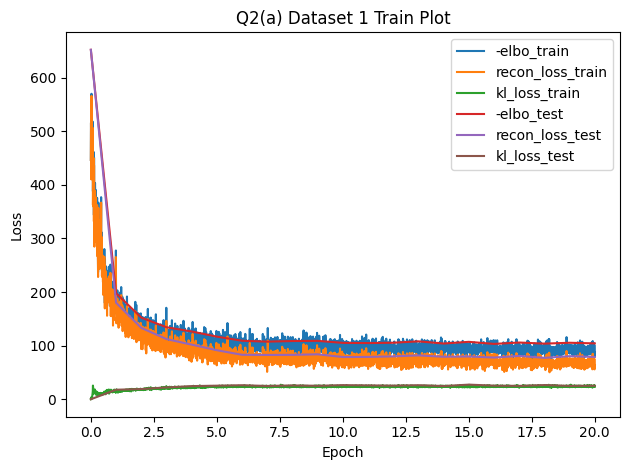

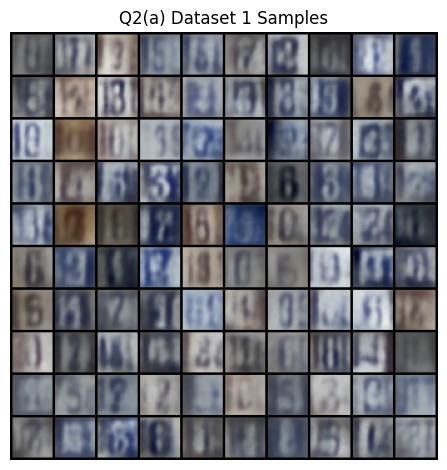

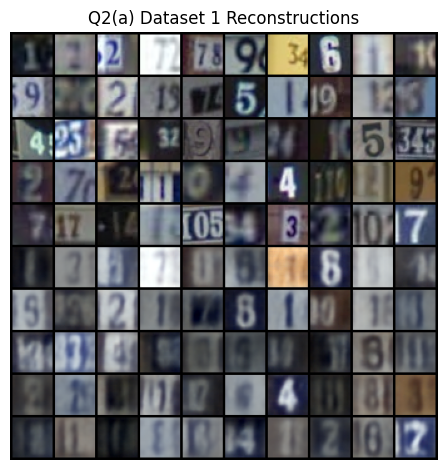

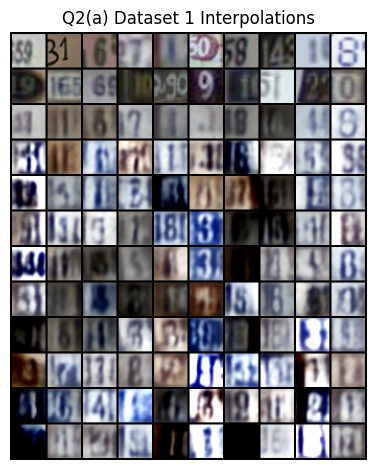

In [ ]:
q2_save_results('a', 1, q2_a)

981411


<ipython-input-14-bbd4a3798f3b>:180: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch, dtype=dtype).to(device)


test loss: 813.459228515625


<ipython-input-14-bbd4a3798f3b>:204: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch, dtype=dtype).to(device)


loss: 213.52622985839844
test loss: 255.22463989257812
loss: 249.4962615966797
test loss: 239.43760681152344
loss: 240.46165466308594
test loss: 241.40280151367188
loss: 266.0706787109375
test loss: 296.3001403808594
loss: 204.12945556640625
test loss: 267.0543518066406
loss: 260.7378845214844
test loss: 257.5652160644531
loss: 234.26287841796875
test loss: 220.23582458496094
loss: 229.40313720703125
test loss: 260.3797607421875
loss: 294.4993591308594
test loss: 289.7930603027344
loss: 223.8976593017578
test loss: 205.92601013183594
loss: 239.72531127929688
test loss: 252.45909118652344
loss: 226.58096313476562
test loss: 251.13723754882812
loss: 264.20965576171875
test loss: 240.9795684814453
loss: 271.71044921875
test loss: 266.4847106933594
loss: 217.3385009765625
test loss: 208.47567749023438
loss: 229.8097381591797
test loss: 233.09750366210938
loss: 237.39505004882812
test loss: 204.62013244628906
loss: 213.60914611816406
test loss: 225.33058166503906
loss: 275.3376770019531
tes

<ipython-input-14-bbd4a3798f3b>:113: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch[:50], dtype=dtype).to(device)
<ipython-input-14-bbd4a3798f3b>:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch[:20], dtype=dtype).to(device) # 20 images


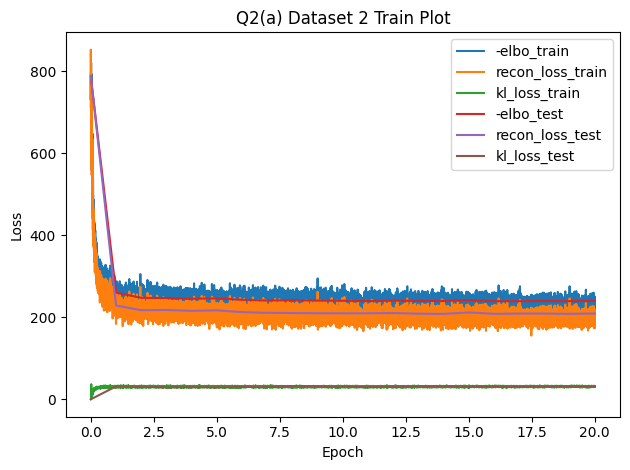

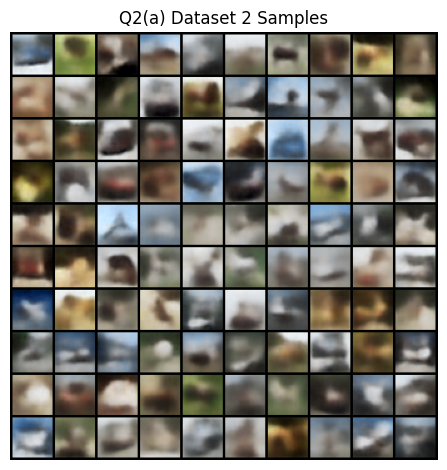

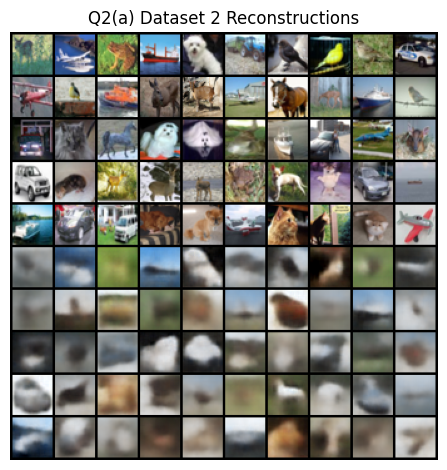

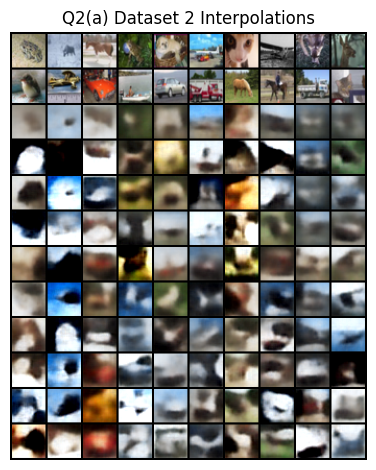

In [ ]:
q2_save_results('a', 2, q2_a)

## Part (b) Hierarchical VAE [20pts]

In this part, we will explore a simplified version of the hierarchical VAE described in [NVAE](https://arxiv.org/pdf/2007.03898.pdf). We will not implement the full NVAE, but rather use some ideas from the paper to explore how to learn a prior distribution p(z).

Implement a hierarchical VAE that follows the following structure.
* $z1$ is a 2x2x12 latent vector where p(z1) is the unit Gaussian.
    * Learn the approximate posterior $q_\theta(z|x) = N(z; \mu_\theta(x), \Sigma_\theta(x))$, where $\mu_\theta(x)$ is the mean vector, and $\Sigma_\theta(x)$ is a diagonal covariance matrix. I.e., same as a normal VAE, but use a matrix latent rather than a vector. Each dimension is independent.
* $z2$ is a 2x2x12 latent vector.
    * $p_\theta(z2|z1)$ is learned, and implemented as a neural network that parameterizes mean (and log std, optionally).
    * $q_\theta(z2|z1,x)$ is also learned. Implement this as a Residual Normal [see NVAE] over the prior $p_\theta(z2|z1)$.
* The decoder should be a function of $z2$ only.

Some helpful hints:
* Two KL losses should be calculated. The first should match $q_\theta(z|x)$ to the unit Gaussian. The second should match $q_\theta(z2|z1,x)$ and $p_\theta(z2|z1)$, and be taken with respect to $q$.
* When calculating the second KL term, utilize the analytic form for the residual normal. When $q_\theta(z2|z1,x) = N(z2; \mu_\theta(z1) + \Delta \mu_\theta(z1,x), \Sigma_\theta(z1)) * \Delta \Sigma_\theta(z1,x))$, use the following form: `kl_z2 = -z2_residual_logstd - 0.5 + (torch.exp(2 * z2_residual_logstd) + z2_residual_mu ** 2) * 0.5`
* When calculating KL, remember to sum over the dimensions of the latent variable before taking the mean over batch.
* For the prior $p_\theta(z2|z1)$, fix standard deviation to be 1. Learn only the mean. This will help with stability in training.

The following network structures may be useful:
```
conv2d(in_channels, out_channels, kernel_size, stride, padding)
transpose_conv2d(in_channels, out_channels, kernel_size, stride, padding)
linear(in_dim, out_dim)

Encoder
        nn.Conv2d(3 + 12, 32, 3, padding=1), # [32, 32, 32]
        LayerNorm(32),
        nn.ReLU(),
        nn.Conv2d(32, 64, 3, stride=2, padding=1), # [64, 16, 16]
        LayerNorm(64),
        nn.ReLU(),
        nn.Conv2d(64, 64, 3, stride=2, padding=1), # [64, 8, 8]
        LayerNorm(64),
        nn.ReLU(),
        nn.Conv2d(64, 64, 3, stride=2, padding=1), # [64, 4, 4]
        LayerNorm(64),
        nn.ReLU(),
        nn.Conv2d(64, 64, 3, stride=2, padding=1), # [64, 2, 2]
        LayerNorm(64),
        nn.ReLU(),
        nn.Conv2d(64, 12*2, 3, padding=1), # [12*2, 2, 2]
We assume encoder networks are of the form p(z'|z,x).
When learning q(z1), an x of all zeros can be used as input.
Upscale z with nearest-neighbor projection before concatenating with x.


Decoder
        nn.ConvTranspose2d(12, 64, 3, padding=1), # [64, 2, 2]
        nn.ReLU(),
        nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1), # [64, 4, 4]
        nn.ReLU(),
        nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1), # [64, 8, 8]
        nn.ReLU(),
        nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1), # [64, 16, 16]
        nn.ReLU(),
        nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), # [32, 32, 32]
        nn.ReLU(),
        nn.Conv2d(32, 3, 3, padding=1), # [3, 32, 32]
```


**You will provide the following deliverables**


1.   Over the course of training, record the average full negative ELBO, reconstruction loss, and KL term of the training data (per minibatch) and test data (for your entire test set). Code is provided that automatically plots the training curves.
2.   Report the final test set performance of your final model
3. 100 samples from your trained VAE
4. 50 real-image / reconstruction pairs (for some $x$, encode and then decode)
5. 10 interpolations of 10 images from your trained VAE (100 images total)




### Solution
Fill out the function below and return the neccessary arguments. Feel free to create more cells if need be

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = torch.float32

class VAE_Encoder(nn.Module):
    def __init__(self, in_shape, zeros):
        super().__init__()
        N, C, H, W = in_shape
        self.zeros = zeros
        self.latent_dim = 2*2*12
        self.out_linear = nn.Linear(4*4*256, 2*12*2*2)
        if zeros == True:
          self.q = nn.ModuleList([
          # conv2d(in_channels, out_channels, kernel_size, stride, padding)
              nn.Conv2d(3+12, 32, 3, 1, 1), # (32, 32, 32)
              nn.LayerNorm((32, 32, 32)),
              nn.ReLU(),
              nn.Conv2d(32, 64, 3, 2, 1),  # (64, 16, 16)
              nn.LayerNorm((64, 16, 16)),
              nn.ReLU(),
              nn.Conv2d(64, 64, 3, 2, 1), # (64, 8, 8)
              nn.LayerNorm((64, 8, 8)),
              nn.ReLU(),
              nn.Conv2d(64, 64, 3, 2, 1),  # (64, 4, 4)
              nn.LayerNorm((64, 4, 4)),
              nn.ReLU(),
              nn.Conv2d(64, 64, 3, 2, 1),  # (64, 2, 2)
              nn.LayerNorm((64, 2, 2)),
              nn.ReLU(),
              nn.Conv2d(64, 12*2, 1, 1)])  # (12*2, 2, 2)
        elif zeros == False:
          self.q = nn.ModuleList([
          # conv2d(in_channels, out_channels, kernel_size, stride, padding)
              nn.Conv2d(3, 32, 3, 1, 1), # (32, 32, 32)
              nn.LayerNorm((32, 32, 32)),
              nn.ReLU(),
              nn.Conv2d(32, 64, 3, 2, 1),  # (64, 16, 16)
              nn.LayerNorm((64, 16, 16)),
              nn.ReLU(),
              nn.Conv2d(64, 64, 3, 2, 1), # (64, 8, 8)
              nn.LayerNorm((64, 8, 8)),
              nn.ReLU(),
              nn.Conv2d(64, 64, 3, 2, 1),  # (64, 4, 4)
              nn.LayerNorm((64, 4, 4)),
              nn.ReLU(),
              nn.Conv2d(64, 64, 3, 2, 1),  # (64, 2, 2)
              nn.LayerNorm((64, 2, 2)),
              nn.ReLU(),
              nn.Conv2d(64, 12*2, 1, 1)])  # (12*2, 2, 2)

    def forward(self, x, z):
        if self.zeros == True:
          out = torch.cat((x, z), dim=1)
        elif self.zeros == False:
          out = x
        for layer in self.q:
          #print(out.shape)
          out = layer(out)
        mu, logstd = torch.chunk(out, 2, dim=1)
        return mu, logstd

class VAE_Decoder(nn.Module):
    def __init__(self, in_shape):
        super().__init__()
        N, C, H, W = in_shape
        self.in_linear = nn.Linear(12*2*2, 4*4*128)
# in_channels, out_channels, kernel_size, stride=1, padding=0, output_padding=0
        self.p = nn.ModuleList([
            # start with [12, 2, 2]
            #nn.ConvTranspose2d(12, 64, 3, padding=1), # [64, 2, 2]
            #nn.ReLU(),
            nn.ConvTranspose2d(128, 128, 4, stride=2, padding=1), # [64, 4, 4]
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), # [64, 8, 8]
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), # [64, 16, 16]
            nn.ReLU(),
            #nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), # [32, 32, 32]
            #nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1)]) # [3, 32, 32]])

    def forward(self, out):
        N, C, H, W = out.shape
        out = self.in_linear(out.reshape((N, 12*2*2)))
        out = F.relu(out)
        N, _ = out.shape
        out = torch.reshape(out, (N, 128, 4, 4))
        for layer in self.p:
            out = layer(out)
        return out

class Latent_Predictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.in_linear = nn.Linear(12*2*2, 4*4*64)
        self.p = nn.ModuleList([
            #nn.ConvTranspose2d(12, 64, 3, padding=1), # [64, 2, 2]
            #nn.ReLU(),
            nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1), # [64, 4, 4]
            nn.ReLU(),
            nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1), # [64, 8, 8]
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, 2, 1),  # (64, 8, 8)
            nn.LayerNorm((64, 8, 8)),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, 2, 1),  # (64, 4, 4)
            nn.LayerNorm((64, 4, 4)),
            nn.Conv2d(64, 64, 3, 2, 1),  # (64, 2, 2)
            nn.LayerNorm((64, 2, 2)),
            nn.ReLU(),
            nn.Conv2d(64, 12, 1, 1)])  # (12, 2, 2)])

    def forward(self, x):
        out = self.in_linear(x)
        out = F.relu(out)
        N, _ = out.shape
        out = torch.reshape(out, (N, 64, 4, 4))
        for layer in self.p:
            out = layer(out)
        return out + x.reshape(N, 12, 2, 2)

class VAE(nn.Module):
    def __init__(self, in_shape):
        super().__init__()
        N, C, H, W = in_shape
        self.hidden_size = 128
        self.q_z_x = VAE_Encoder(in_shape, zeros=False)
        self.q_z2_z1x = VAE_Encoder(in_shape, zeros=True)
        self.decoder = VAE_Decoder(in_shape)
        # p(z2|z1), only learning the mean (set std=1)
        self.p_z2_z1 = Latent_Predictor()

    def log_prob(self, x):
        N, C, H, W = x.shape
        x = 2 * x - 1
        z1_prior = torch.distributions.normal.Normal(torch.tensor(0, dtype=dtype), torch.tensor(1, dtype=dtype))
        # q(z1|x)
        qz1_mu, qz1_logstd = self.q_z_x(x, torch.zeros((N, 12, H, W), dtype=dtype).to(device))
        # sample z1 with reparameterization trick
        z1_sample = qz1_mu + qz1_logstd.exp()*z1_prior.sample(sample_shape=qz1_mu.shape).to(device)
        # print(z1_sample.shape)
        # p(z2|z1) -> std is fixed to be 1
        pz2_z1_mu = self.p_z2_z1(z1_sample.reshape(N, 12*2*2)).reshape((N, 12, 2, 2)) #+ qz1_mu
        # get residual normal
        d_qz2_z1_mu, d_qz2_z1_logstd = self.q_z2_z1x(x, F.interpolate(z1_sample, size=(32, 32)))
        # sample z2 with reparameterization trick
        residual_mu = pz2_z1_mu+d_qz2_z1_mu
        residual_logstd = d_qz2_z1_logstd

        z2_sample = residual_mu + residual_logstd.exp()*z1_prior.sample(sample_shape=qz1_mu.shape).to(device)
        # decode
        x_out = self.decoder(z2_sample)
        # reconstruction_loss with MSE
        recon_loss_fn = nn.MSELoss(reduction='none')
        recon_loss = recon_loss_fn(x, x_out)
        recon_loss = recon_loss.view(recon_loss.shape[0], -1).sum(1).mean()
        #  DKL = 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2) same shape as latent
        DKL = -0.5 * (1 + 2 * qz1_logstd - qz1_mu.pow(2) - qz1_logstd.exp().pow(2))
        DKL = DKL.sum(1).mean()
        # DKL for residual normal: kl_z2 = -z2_residual_logstd - 0.5 \
        # + (torch.exp(2 * z2_residual_logstd) + z2_residual_mu ** 2) * 0.5
        R_DKL = -residual_logstd - 0.5 + (torch.exp(2 * residual_logstd) + residual_mu ** 2) * 0.5
        R_DKL = R_DKL.sum(1).mean()
        # loss
        log_px = recon_loss + 1.2*(DKL + R_DKL)
        #print(DKL)
        #print(recon_loss)
        return log_px, recon_loss, DKL

    def sample(self, z1_sample, z1_mu):
        N, C, H, W = z1_sample.shape
        mean = torch.zeros(z1_sample.shape, dtype=dtype).to(device)
        std = torch.ones(z1_sample.shape, dtype=dtype).to(device)
        pz2_z1_mu = self.p_z2_z1(z1_sample.reshape(N, 12*2*2)).reshape((N, 12, 2, 2))
        z2_sample = pz2_z1_mu + torch.normal(mean, std).reshape((N, 12, 2, 2))
        samples = self.decoder(z2_sample)
        samples = torch.permute(samples, (0, 2, 3, 1))
        samples = (samples*0.5+0.5)*255
        return samples

    def reconstruct(self, dataloader):
      self.eval()
      with torch.no_grad():
        for batch in dataloader:
          x = torch.tensor(batch[:50], dtype=dtype).to(device)
          N, C, H, W = x.shape
          x /= 255
          # pass through networks
          x = 2 * x - 1
          z1_prior = torch.distributions.normal.Normal(torch.tensor(0, dtype=dtype), torch.tensor(1, dtype=dtype))
          # q(z1|x)
          qz1_mu, qz1_logstd = self.q_z_x(x, torch.zeros((N, 12, H, W), dtype=dtype).to(device))
          # sample z1 with reparameterization trick
          z1_sample = qz1_mu + qz1_logstd.exp()*z1_prior.sample(sample_shape=qz1_mu.shape).to(device)
          #print(z1_sample.shape)
          # p(z2|z1) -> std is fixed to be 1
          pz2_z1_mu = self.p_z2_z1(z1_sample.reshape(N, 12*2*2)).reshape(((N, 12, 2, 2))) + qz1_mu
          # compute residual normal
          d_qz2_z1_mu, d_qz2_z1_logstd = self.q_z2_z1x(x, F.interpolate(z1_sample, size=(32, 32)))
          # sample z2 with reparameterization trick
          residual_mu = pz2_z1_mu+d_qz2_z1_mu
          residual_logstd = d_qz2_z1_logstd
          # decode
          z2_sample = residual_mu + residual_logstd.exp()*z1_prior.sample(sample_shape=qz1_mu.shape).to(device)
          samples = self.decoder(z2_sample)
          samples = torch.permute(samples, (0, 2, 3, 1))
          samples = (samples*0.5+0.5)*255
          # deprocess x
          x_out = torch.permute(x, (0, 2, 3, 1))
          x_out = (x_out*0.5+0.5)*255
          return torch.cat((x_out, samples), dim=0)

    ''' a (100, 32, 32, 3) numpy array of 10 interpolations of length 10 between
      pairs of test images. The output should be those 100 images flattened into
      the specified shape with values in {0, ..., 255} '''

    def interpolate(self, dataloader):
      self.eval()
      with torch.no_grad():
        for batch in dataloader:
          x = torch.tensor(batch[:20], dtype=dtype).to(device) # 20 images
          N, C, H, W = x.shape
          x /= 255
          x = 2 * x - 1
          z_mu, z_logstd = self.q_z_x(x, torch.zeros((N, 12, H, W), dtype=dtype).to(device)) # shape (20, 12, 2, 2)
          # need to interpolate and get (10-80-10, 16)
          z_mu, z_logstd = self.interpolate_latents(z_mu, z_logstd)
          z_prior = torch.distributions.normal.Normal(torch.tensor(0, dtype=dtype), torch.tensor(1, dtype=dtype))
          z_dist = torch.distributions.normal.Normal(z_mu, z_logstd.exp())
          # reparameterization trick
          z_sample = z_mu + z_logstd.exp() * z_prior.sample(sample_shape=z_mu.shape).to(device)
          # decode
          samples = self.sample(z_sample, z_mu)
          x_out = torch.permute(x, (0, 2, 3, 1))
          x_out = (x_out*0.5+0.5)*255
          return torch.cat((x_out, samples), dim=0)

    def interpolate_latents(self, z_mu, z_logstd):
    # latents are shape (20, 16), interpolate and return (10-80-10, 16)
    # split mu and logstd in half to get (10, 16)
      z_mu_1, z_mu_2 = torch.chunk(z_mu, 2, dim=0)
      z_logstd_1, z_logstd_2 = torch.chunk(z_logstd, 2, dim=0)
      # will concat interpolations to these
      z_mu_out = z_mu_1
      z_logstd_out = z_logstd_1
      # interpolate from z_1 -> z_2
      d_mu = z_mu_2 - z_mu_1
      d_logstd = z_logstd_2 - z_logstd_1
      for i in range(1, 10):
        new_mu = z_mu_1 + i*(d_mu/9)
        new_logstd = z_mu_1 + i*(d_logstd/9)
        z_mu_out = torch.cat((z_mu_out, new_mu), dim=0)
        z_logstd_out = torch.cat((z_logstd_out, new_mu), dim=0)
      return z_mu_out, z_logstd_out

def test(model, dataloader):
    model.eval()
    losses = []
    recon_losses = []
    DKLs = []
    with torch.no_grad():
        for batch in dataloader:
            x = torch.tensor(batch, dtype=dtype).to(device)
            x = x / 255

            loss, recon_loss, DKL = model.log_prob(x)
            losses.append(loss.item())
            recon_losses.append(recon_loss.item())
            DKLs.append(DKL.item())
        print(f'test loss: {loss.item()}')

        return np.array(losses).mean(), np.array(recon_losses).mean(), np.array(DKLs).mean()

def train(train_dataloader, test_dataloader, model, epochs, optimizer):
    losses = []
    recon_losses = []
    DKLs = []
    test_losses = []
    test_recon_losses = []
    test_DKLs = []
    l, r, d = test(model, test_dataloader)
    test_losses.append(l)
    test_recon_losses.append(r)
    test_DKLs.append(d)
    for i in range(epochs):
        for batch in train_dataloader:
            x = torch.tensor(batch, dtype=dtype).to(device)
            x /= 255

            loss, recon_loss, DKL = model.log_prob(x)
            losses.append(loss.item())
            recon_losses.append(recon_loss.item())
            DKLs.append(DKL.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f'loss: {loss.item()}')

        l, r, d = test(model, test_dataloader)
        test_losses.append(l)
        test_recon_losses.append(r)
        test_DKLs.append(d)

    return np.stack((np.array(losses), np.array(recon_losses), np.array(DKLs)), axis=1), \
        np.stack((np.array(test_losses), np.array(test_recon_losses), np.array(test_DKLs)), axis=1)


def q2_b(train_data, test_data, dset_id):
    """
    train_data: An (n_train, 32, 32, 3) uint8 numpy array of color images with values in {0, ..., 255}
    test_data: An (n_test, 32, 32, 3) uint8 numpy array of color images with values in {0, ..., 255}
    dset_id: An identifying number of which dataset is given (1 or 2). Most likely
               used to set different hyperparameters for different datasets

    Returns
    - a (# of training iterations, 3) numpy array of full negative ELBO, reconstruction loss E[-p(x|z)],
      and KL term E[KL(q(z|x) | p(z))] evaluated every minibatch
    - a (# of epochs + 1, 3) numpy array of full negative ELBO, reconstruciton loss E[-p(x|z)],
      and KL term E[KL(q(z|x) | p(z))] evaluated once at initialization and after each epoch
    - a (100, 32, 32, 3) numpy array of 100 samples from your VAE with values in {0, ..., 255}
    - a (100, 32, 32, 3) numpy array of 50 real image / reconstruction pairs
      FROM THE TEST SET with values in {0, ..., 255}
    - a (100, 32, 32, 3) numpy array of 10 interpolations of length 10 between
      pairs of test images. The output should be those 100 images flattened into
      the specified shape with values in {0, ..., 255}
    """

    """ YOUR CODE HERE """
    train_data = np.transpose(train_data, axes=[0, 3, 1, 2]).astype(np.float32)  # NCHW 20000 x 3 x 32 x 32
    test_data = np.transpose(test_data, axes=[0, 3, 1, 2]).astype(np.float32)  # NCHW 6838 x 3 x 32 x 32
    train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
    test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=True)
    # model
    model = VAE(in_shape = (64, 3, 32, 32))
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    EPOCHS = 20
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(num_params)

    train_results, test_results = train(train_dataloader, test_dataloader, model, EPOCHS, optimizer)
    # sample z from unit gaussian prior
    z_prior = torch.distributions.normal.Normal(torch.tensor(0, dtype=dtype), torch.tensor(1, dtype=dtype))
    z_sample = z_prior.sample(sample_shape=(100, 12, 2, 2)).to(device)
    samples_1 = model.sample(z_sample, torch.zeros_like(z_sample))
    reconstructions = model.reconstruct(test_dataloader)
    interpolations = model.interpolate(test_dataloader)

    print(train_results.shape)
    return train_results, test_results, \
      samples_1.cpu().detach().numpy(), \
      reconstructions.cpu().detach().numpy(), \
      interpolations.cpu().detach().numpy()


### Results
Once you've finished `q2_b`, execute the cells below to visualize and save your results.

2102783


<ipython-input-93-15bb08db7bdd>:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch, dtype=dtype).to(device)


test loss: 678.8612060546875


<ipython-input-93-15bb08db7bdd>:290: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch, dtype=dtype).to(device)


loss: 248.1160125732422
test loss: 210.49053955078125
loss: 137.33229064941406
test loss: 132.25531005859375
loss: 102.31842041015625
test loss: 96.0330810546875
loss: 98.54928588867188
test loss: 150.2147216796875
loss: 114.36746215820312
test loss: 105.50947570800781
loss: 80.41104125976562
test loss: 97.53143310546875
loss: 68.3701171875
test loss: 161.35536193847656
loss: 82.3499755859375
test loss: 75.91320037841797
loss: 75.913330078125
test loss: 93.4206771850586
loss: 90.62895202636719
test loss: 89.54287719726562
loss: 64.12584686279297
test loss: 71.66996002197266
loss: 101.51190948486328
test loss: 75.8966293334961
loss: 68.4068603515625
test loss: 77.51107025146484
loss: 76.26018524169922
test loss: 92.63467407226562
loss: 71.63177490234375
test loss: 92.29376220703125
loss: 81.47333526611328
test loss: 57.73371887207031
loss: 79.14132690429688
test loss: 106.06153106689453
loss: 55.35700225830078
test loss: 66.11002349853516
loss: 73.95272064208984
test loss: 122.495834350

<ipython-input-93-15bb08db7bdd>:188: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch[:50], dtype=dtype).to(device)
<ipython-input-93-15bb08db7bdd>:224: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch[:20], dtype=dtype).to(device) # 20 images


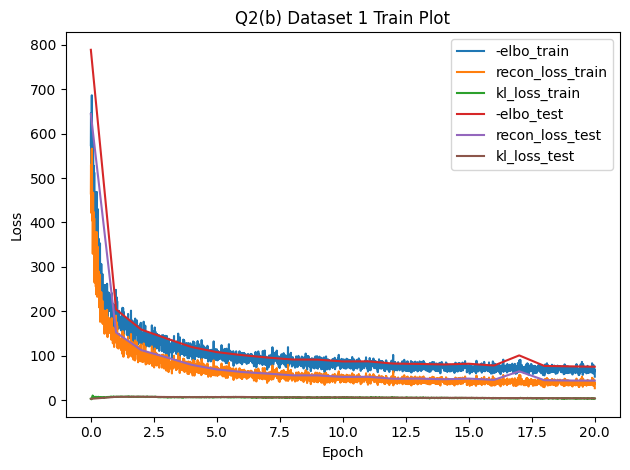

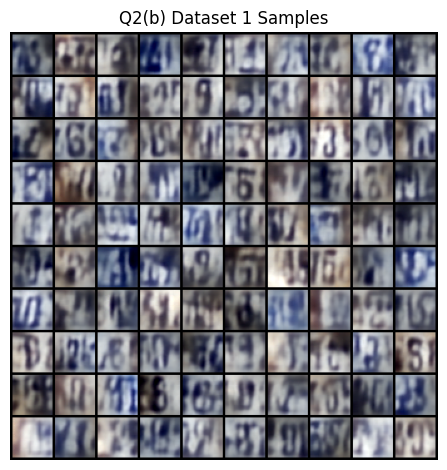

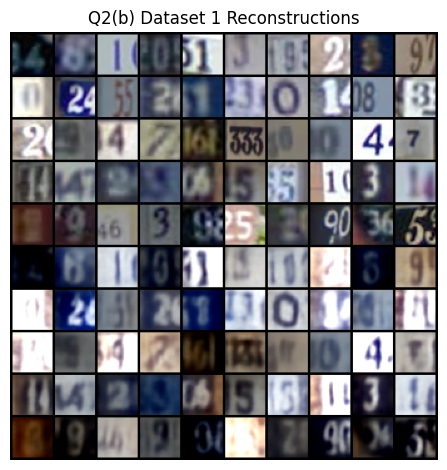

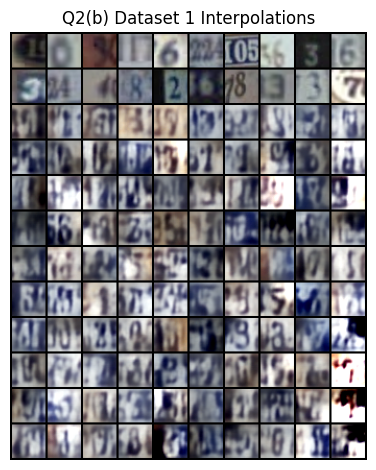

In [ ]:
q2_save_results('b', 1, q2_b)

In [ ]:
q2_save_results('b', 2, q2_b)

2102783


<ipython-input-8-89f045ebffb6>:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch, dtype=dtype).to(device)


test loss: 818.5809936523438


<ipython-input-8-89f045ebffb6>:290: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch, dtype=dtype).to(device)


loss: 218.62130737304688
test loss: 203.25009155273438
loss: 187.92823791503906
test loss: 179.19708251953125
loss: 173.66708374023438
test loss: 158.55039978027344
loss: 168.7313690185547
test loss: 141.70913696289062
loss: 177.46548461914062
test loss: 167.11790466308594


# Question 3: VQ-VAE [40pts]
In this question, you with train a [VQ-VAE](https://arxiv.org/abs/1711.00937) on the colored shapes dataset and SVHN. If you are confused on how the VQ-VAE works, you may find [Lilian Weng's blogpost](https://lilianweng.github.io/lil-log/2018/08/12/from-autoencoder-to-beta-vae.html#vq-vae-and-vq-vae-2) to be useful.

You may experiment with different hyperparameters and architecture designs, but the following designs for the VQ-VAE architecture may be useful.

```
conv2d(in_channels, out_channels, kernel_size, stride, padding)
transpose_conv2d(in_channels, out_channels, kernel_size, stride, padding)
linear(in_dim, out_dim)
batch_norm2d(dim)

residual_block(dim)
    batch_norm2d(dim)
    relu()
    conv2d(dim, dim, 3, 1, 1)
    batch_norm2d(dim)
    relu()
    conv2d(dim, dim, 1, 1, 0)

Encoder
    conv2d(3, 256, 4, 2, 1) 16 x 16
    batch_norm2d(256)
    relu()
    conv2d(256, 256, 4, 2, 1) 8 x 8
    residual_block(256)
    residual_block(256)

Decoder
    residual_block(256)
    residual_block(256)
    batch_norm2d(256)
    relu()
    transpose_conv2d(256, 256, 4, 2, 1) 16 x 16
    batch_norm2d(256)
    relu()
    transpose_conv2d(256, 3, 4, 2, 1) 32 x 32
```

A few other tips:
*   Use a codebook with $K = 128$ latents each with a $D = 256$ dimensional embedding vector
*   You should initialize each element in your $K\times D$ codebook to be uniformly random in $[-1/K, 1/K]$
*   Use batch size 128 with a learning rate of $10^{-3}$ and an Adam optimizer
*   Center and scale your images to $[-1, 1]$
*   Supposing that $z_e(x)$ is the encoder output, and $z_q(x)$ is the quantized output using the codebook, you can implement the straight-through estimator as follows (where below is fed into the decoder):
  * `(z_q(x) - z_e(x)).detach() + z_e(x)` in Pytorch
  * `tf.stop_gradient(z_q(x) - z_e(x)) + z_e(x)` in Tensorflow.

In addition to training the VQ-VAE, you will also need to train a Transformer prior on the categorical latents in order to sample. Feel free to use your implementation for HW1! You should flatten the VQ-VAE tokens into a [H x W] sequence, and use a start token.

**You will provide the following deliverables**


1.   Over the course of training, record the average loss of the training data (per minibatch) and test data (for your entire test set) **for both your VQ-VAE and Transformer prior**. Code is provided that automatically plots the training curves.
2. Report the final test set performances of your final models
3. 100 samples from your trained VQ-VAE and Transformer prior
4. 50 real-image / reconstruction pairs (for some $x$, encode and then decode)

## Solution
Fill out the function below and return the neccessary arguments. Feel free to create more cells if need be

In [ ]:
import torch
def nearest_neighbours(z, codebook):
    # z is (N, d, H, W) and codebook is (K, d)
    K, d = codebook.shape
    N, d, H, W = z.shape
    z = z.reshape((N, d, H*W))
    z = z.unsqueeze(dim=-1).repeat(1, 1, 1, K) # (N, d, H*W, 1) -> (N, d, H*W, K)

    # (K, d) -> (d, K) -> (d, 1, K) -> (d, H*W, K)
    codebook = codebook.permute((1, 0)).unsqueeze(dim=1).repeat((1, H*W, 1))

    distances = torch.square(z-codebook).sum(dim=1) # (N, H*W, K)
    indices = torch.argmin(distances, dim=2) # (N, H*W)
    return indices

# N=10, d=5, H=W=3, K=4

z = torch.randn(450).reshape((10, 5, 3, 3))
codebook = torch.randn(20).reshape((4, 5))
nearest_neighbours(z, codebook)
t = torch.arange(50).reshape((10, 5))
# Create an array of indices
print(t)
indices = torch.randint(10, (10, 3))
print(t[indices])
print(t[indices].shape)


tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19],
        [20, 21, 22, 23, 24],
        [25, 26, 27, 28, 29],
        [30, 31, 32, 33, 34],
        [35, 36, 37, 38, 39],
        [40, 41, 42, 43, 44],
        [45, 46, 47, 48, 49]])
tensor([[[20, 21, 22, 23, 24],
         [10, 11, 12, 13, 14],
         [40, 41, 42, 43, 44]],

        [[45, 46, 47, 48, 49],
         [45, 46, 47, 48, 49],
         [ 0,  1,  2,  3,  4]],

        [[40, 41, 42, 43, 44],
         [30, 31, 32, 33, 34],
         [40, 41, 42, 43, 44]],

        [[30, 31, 32, 33, 34],
         [20, 21, 22, 23, 24],
         [45, 46, 47, 48, 49]],

        [[45, 46, 47, 48, 49],
         [10, 11, 12, 13, 14],
         [ 0,  1,  2,  3,  4]],

        [[30, 31, 32, 33, 34],
         [40, 41, 42, 43, 44],
         [45, 46, 47, 48, 49]],

        [[20, 21, 22, 23, 24],
         [45, 46, 47, 48, 49],
         [20, 21, 22, 23, 24]],

        [[25, 26, 27, 28, 29],
   

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = torch.float32

class MultiHeadAttention(nn.Module):
  def __init__(self, d_m, d_k, d_v, num_heads):
    super().__init__()
    self.d_m = d_m
    self.d_k = d_k
    self.d_v = d_v
    self.h = num_heads
    self.k_linear = nn.Linear(d_m, self.h*d_k)
    self.q_linear = nn.Linear(d_m, self.h*d_k)
    self.v_linear = nn.Linear(d_m, self.h*d_v)
    self.out_linear = nn.Linear(self.h*self.d_v, self.d_m)
    # mask
    self.mask = None

  def forward(self, x): # x is shape (N, L, d_m)
    N, L, _ = x.shape
    # create mask
    if self.mask == None:
      self.mask = torch.triu(
        torch.full((L, L), float('-inf'), dtype=dtype, device=device),
        diagonal=1)
    # project to h*d_k (N, L, h*d_k) and reshape to (N, h, L, d_k)
    Q = self.q_linear(x).reshape(N, L, self.h, self.d_k).permute((0, 2, 1, 3))
    K = self.k_linear(x).reshape(N, L, self.h, self.d_k).permute((0, 2, 1, 3))
    V = self.v_linear(x).reshape(N, L, self.h, self.d_v).permute((0, 2, 1, 3))
    attention = F.softmax(torch.matmul(Q, torch.transpose(K, 2, 3))*(self.d_k**(-1/2)) + self.mask, dim=-1)
    attention = torch.matmul(attention, V)
    attention = attention.permute((0, 2, 1, 3)).reshape(N, L, self.h*self.d_v)
    # attention is shape (N, L, h*d_v)
    out = self.out_linear(attention)
    return out

class TransformerBlock(nn.Module):
  def __init__(self, attention_args):
    super().__init__()
    d_m, d_k, d_v, num_heads = attention_args
    self.AttentionBlock = MultiHeadAttention(d_m, d_k, d_v, num_heads)
    self.LayerNorm = nn.LayerNorm(d_m) # normalize only across last dim, not seq length
    self.MLP = nn.Sequential(
        nn.Linear(d_m, 4*d_m),
        nn.GELU(),
        nn.Linear(4*d_m, d_m)
    )

  def forward(self, x): # x is shape (N, L, d_m)
    # layernorm
    n = self.LayerNorm(x)
    # attention
    a = self.AttentionBlock(n) + x
    # mlp
    out = a + self.MLP(self.LayerNorm(a))
    return out

class Transformer(nn.Module):
    def __init__(self, attention_args, n_blocks, seq_length, vocab_size, d_m):
      super().__init__()
      self.seq_length = seq_length
      self.vocab_size = vocab_size
      self.d_m = d_m
      self.embedding = nn.Embedding(vocab_size+1, d_m)
      self.positional_embedding = nn.Parameter(torch.zeros((seq_length, d_m), dtype=dtype), requires_grad=True)
      # transformer blocks
      self.blocks = nn.ModuleList([])
      for n in range(n_blocks):
        self.blocks.append(TransformerBlock(attention_args))
      # out linear
      self.out_linear = nn.Linear(d_m, vocab_size)
      # start token
      self.start_token = vocab_size

    def forward(self, x):
      #
      x = x.int()
      out = self.embedding(x) + self.positional_embedding
      # transformer blocks
      for block in self.blocks:
        out = block(out)
      # out linear
      out_logits = self.out_linear(out)
      return out_logits

    def loss(self, x, target):
      target = target.long()
      loss_fn = nn.CrossEntropyLoss()
      out_logits = self.forward(x).permute((0, 2, 1)) # shape (N, vocab_size, L)
      loss = loss_fn(out_logits, target)
      return loss

    def sample(self, n_samples):
      self.eval()
      with torch.no_grad():
        # initialise inputs/outputs with start token + zeros (N, L)
        # where each entry is the index of a specific token in the vocab
        in_tensor = torch.concatenate(
            (self.start_token*torch.ones((n_samples, 1), dtype=dtype),
            torch.zeros((n_samples, self.seq_length), dtype=dtype)), dim=1
        ).to(device) # (N, L+1)
        # outputs is (N, L)
        out_tensor = torch.zeros((n_samples, self.seq_length), dtype=dtype).to(device) # (N, L)
        for i in range(self.seq_length):
          #print(in_tensor[0, :i])
          #print(out_tensor[0, :i])
          #print(' ')
          out_logits = self(in_tensor[:, :-1]) # (N, L, vocab_size)
          out_probs = F.softmax(out_logits[:, i, :], dim=1) # (N, vocab_size)
          #print(out_probs[0])
          prob_samples = torch.multinomial(out_probs, 1) # (N, 1)
          out_tensor[:, i] = prob_samples.squeeze()
          in_tensor[:, i+1] = prob_samples.squeeze()
        return out_tensor.cpu().detach().numpy()

    def get_input_sequence(self, batch):
      '''
      :param batch: shape (batch_size, seq_length)
      remove last token in each sequence, prepend start token to each sequence
      '''
      batch = np.array(batch) # (N, L)
      batch_size, seq_length = batch.shape
      # Remove the last token from each sequence
      batch_trimmed = batch[:, :-1]
      # Prepend start token (int = vocab_size) to each sequence
      start_token = np.ones((batch_size, 1))*self.vocab_size # Replace this with the actual start token
      input_data = np.concatenate([start_token, batch_trimmed], axis=1)
      return input_data

def train(model, train_dataloader, test_dataloader, optimizer, epochs):
  def test(model, test_dataloader, optimizer):
    model.eval()
    epoch_losses = []
    with torch.no_grad():
      for batch in test_dataloader:
        # get input sequence
        x = torch.tensor(model.get_input_sequence(batch), dtype=int).to(device)
        #print(x[0])
        target = torch.tensor(batch, dtype=dtype).to(device)
        loss = model.loss(x, target)
        epoch_losses.append(loss.item())
      test_loss = np.array(epoch_losses).mean()
      print(test_loss)
      return test_loss

  model.train()
  train_losses = []
  test_losses = []
  test_losses.append(test(model, test_dataloader, optimizer))
  loss_fn = nn.CrossEntropyLoss()
  for epoch in range(epochs):
    for batch in train_dataloader:
      # get input sequence
      x = torch.tensor(model.get_input_sequence(batch), dtype=int).to(device)
      target = torch.tensor(batch, dtype=int).to(device)
      target = target.long()
      out_logits = model.forward(x).permute((0, 2, 1)) # shape (N, vocab_size, L)
      loss = loss_fn(out_logits, target)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      train_losses.append(loss.item())
      #print(loss.item())

    test_loss = test(model, test_dataloader, optimizer)
    test_losses.append(test_loss)
  return np.array(train_losses), np.array(test_losses)

def q3_a(train_data, test_data, image_shape, dset_id):
  """
  train_data: A (n_train, H, W, 1) uint8 numpy array of color images with values in {0, 1}
  test_data: A (n_test, H, W, 1) uint8 numpy array of color images with values in {0, 1}
  image_shape: (H, W, 1), height, width, and # of channels of the image
  dset_id: An identifying number of which dataset is given (1 or 2). Most likely
           used to set different hyperparameters for different datasets

  Returns
  - a (# of training iterations,) numpy array of train_losses evaluated every minibatch
  - a (# of epochs + 1,) numpy array of test_losses evaluated once at initialization and after each epoch
  - a numpy array of size (100, H, W, 1) of samples with values in {0, 1}
  """
  N, H, W, C = train_data.shape
  # reshape (N, H, W, C) to (N, L)
  train_data = np.squeeze(train_data).reshape(N, H*W)
  test_data = np.squeeze(test_data).reshape(test_data.shape[0], H*W)
  train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
  test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=True)
  # model params
  # (attention_args), n_blocks, seq_length, vocab_size, d_m
  # (d_m, d_k, d_v, num_heads)
  n_blocks = 2
  seq_length = H*W
  vocab_size = 2
  d_m = 128
  d_k = 256
  d_v = 256
  num_heads = 4
  model = Transformer((d_m, d_k, d_v, num_heads), n_blocks, seq_length, vocab_size, d_m)
  model.to(device)
  # hyperparams
  optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
  epochs = 15
  num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
  print(num_params)
  # train
  train_losses, test_losses = train(model, train_dataloader, test_dataloader, optimizer, epochs)
  # sample
  samples = model.sample(n_samples=100)
  samples = samples.reshape(samples.shape[0], H, W, 1)
  return train_losses, test_losses, samples

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = torch.float32

class ResBlock(nn.Module):
  def __init__(self, dim):
    super().__init__()
    self.d = dim
    self.net = nn.ModuleList([
      nn.BatchNorm2d(num_features=self.d),
      nn.ReLU(),
      nn.Conv2d(self.d, self.d, 3, 1, 1),
      nn.BatchNorm2d(num_features=self.d),
      nn.ReLU(),
      nn.Conv2d(self.d, self.d, 1, 1, 0)
    ])

  def forward(self, x):
    out = x
    for layer in self.net:
      out = layer(out)
    return out + x

class Encoder(nn.Module):
  def __init__(self, dim):
    super().__init__()
    self.d = dim
    self.net = nn.ModuleList([
      nn.Conv2d(3, self.d, 4, 2, 1), # 16 x 16
      nn.BatchNorm2d(self.d),
      nn.ReLU(),
      nn.Conv2d(self.d, self.d, 4, 2, 1), # 8 x 8
      ResBlock(self.d),
      ResBlock(self.d)
    ])

  def forward(self, x):
    for layer in self.net:
      x = layer(x)
    return x

class Decoder(nn.Module):
  def __init__(self, dim):
    super().__init__()
    self.d = dim
    self.net = nn.ModuleList([
      ResBlock(self.d),
      ResBlock(self.d),
      nn.BatchNorm2d(self.d),
      nn.ReLU(),
      nn.ConvTranspose2d(self.d, self.d, 4, 2, 1), # 16 x 16
      nn.BatchNorm2d(self.d),
      nn.ReLU(),
      nn.ConvTranspose2d(self.d, 3, 4, 2, 1), # 32 x 32
    ])

  def forward(self, x):
    for layer in self.net:
      x = layer(x)
    return x

class VQ_VAE(nn.Module):
  def __init__(self, dim, K):
    super().__init__()
    self.d = dim
    self.K = K
    self.H = 8
    self.encoder = Encoder(self.d)
    self.decoder = Decoder(self.d)
    self.codebook = nn.Parameter(
        torch.nn.init.uniform_(torch.empty((K, dim)), a=-1/K, b=1/K),
        requires_grad=True)

    n_blocks = 8
    seq_length = self.H*self.H
    vocab_size = K
    d_m = 128
    d_k = 256
    d_v = 256
    num_heads = 8
    self.transformer = Transformer((d_m, d_k, d_v, num_heads), n_blocks, seq_length, vocab_size, d_m)

  def nearest_neighbours(self, z):
    # z is (N, d, H, W) and codebook is (K, d)

    N, d, H, W = z.shape
    z = z.reshape((N, d, H*W))
    z = z.unsqueeze(dim=-1).repeat(1, 1, 1, self.K) # (N, d, H*W, 1) -> (N, d, H*W, K)

    # (K, d) -> (d, K) -> (d, 1, K) -> (d, H*W, K)
    codebook = self.codebook.permute((1, 0)).unsqueeze(dim=1).repeat((1, H*W, 1))
    distances = torch.square(z-codebook).sum(dim=1) # (N, H*W, K)
    indices = torch.argmin(distances, dim=2) # (N, H*W)
    return H, W, indices

  def loss(self, x):
    x = x / 255
    x = 2 * x - 1
    N, C, _, _ = x.shape
    H, W, indices, z = self.get_indices(x)
    codewords = self.codebook[indices]# (N, H*W, d)
    codewords = codewords.permute((0, 2, 1)).reshape((N, self.d, H, W))
    out = self.decoder((codewords - z).detach() + z)
    # loss
    loss_fn = nn.MSELoss()
    # recon loss + embedding loss + commitment loss
    loss = loss_fn(x, out) + loss_fn(z.detach(), codewords) + loss_fn(codewords.detach(), z)
    return loss

  def get_indices(self, x):
    N, C, _, _ = x.shape
    z = self.encoder(x)
    H, W, indices = self.nearest_neighbours(z)
    return H, W, indices, z

  def sample(self, n_samples):
    indices = self.transformer.sample(n_samples)
    codewords = self.codebook[indices]
    codewords = codewords.permute((0, 2, 1)).reshape((n_samples, self.d, self.H, self.H))
    out = self.decoder(codewords)
    # deprocess outputs
    out = torch.permute(out, (0, 2, 3, 1))
    out = (out*0.5+0.5)*255
    return out

  def reconstruct(self, dataloader):
      n_samples=50
      self.eval()
      with torch.no_grad():
        for batch in dataloader:
          x = torch.tensor(batch[:n_samples], dtype=dtype).to(device)
          x = x / 255
          x = 2 * x - 1
          H, W, indices, z = self.get_indices(x)
          codewords = self.codebook[indices] # (N, H*W, d)
          codewords = codewords.permute((0, 2, 1)).reshape((n_samples, self.d, self.H, self.H))
          samples = self.decoder(codewords)
          # deprocess samples
          samples = torch.permute(samples, (0, 2, 3, 1))
          samples = (samples*0.5+0.5)*255
          # deprocess x
          x_out = torch.permute(x, (0, 2, 3, 1))
          x_out = (x_out*0.5+0.5)*255
          return torch.cat((x_out, samples), dim=0)

def train(model, train_dataloader, test_dataloader, optimizer, epochs):
  def test(model, test_dataloader, optimizer):
    test_losses = []
    model.eval()
    with torch.no_grad():
      for batch in test_dataloader:
        x = torch.tensor(batch, dtype=dtype).to(device)
        loss = model.loss(x)
        test_losses.append(loss.item())
        test_loss = np.array(test_losses).mean()

      print(test_loss)
      return test_loss

  # first train VAE
  model.train()
  VAE_train_losses = []
  VAE_test_losses = []
  VAE_test_losses.append(test(model, test_dataloader, optimizer))
  for epoch in range(epochs):
    for batch in train_dataloader:
      x = torch.tensor(batch, dtype=dtype).to(device)
      loss = model.loss(x)

      VAE_train_losses.append(loss.item())
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    VAE_test_losses.append(test(model, test_dataloader, optimizer))

  print("VAE done")

  # then train the transformer
  def transformer_test(model, test_dataloader, optimizer):
    epoch_losses = []
    model.eval()
    with torch.no_grad():
      for batch in test_dataloader:
        # preprocess into transformer data
        x = batch / 255
        x = 2 * x - 1
        _, _, indices, z = model.get_indices(torch.tensor(x, dtype=dtype).to(device))
        input_sequence = model.transformer.get_input_sequence(indices.cpu().detach())
        input_sequence = torch.tensor(input_sequence).to(device)
        target = torch.tensor(indices, dtype=int).to(device)
        loss = model.transformer.loss(input_sequence, target)
        epoch_losses.append(loss.item())
        indices = model.transformer.sample(10)

      test_loss = np.array(epoch_losses).mean()
      print(test_loss)
      return test_loss

  transformer_test_losses = []
  transformer_train_losses = []
  transformer_test_losses.append(transformer_test(model, test_dataloader, optimizer))

  for epoch in range(epochs):
    for batch in train_dataloader:
      # preprocess into transformer data
      x = batch / 255
      x = 2 * x - 1
      _, _, indices, z = model.get_indices(torch.tensor(x, dtype=dtype).to(device))
      input_sequence = model.transformer.get_input_sequence(indices.cpu().detach())
      input_sequence = torch.tensor(input_sequence).to(device)
      target = torch.tensor(indices, dtype=int).to(device)
      loss = model.transformer.loss(input_sequence, target)

      transformer_train_losses.append(loss.item())
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

    transformer_test_losses.append(transformer_test(model, test_dataloader, optimizer))

  return np.array(VAE_train_losses), np.array(VAE_test_losses), \
    np.array(transformer_train_losses), np.array(transformer_test_losses) \


def q3(train_data, test_data, dset_id):
    """
    train_data: An (n_train, 32, 32, 3) uint8 numpy array of color images with values in [0, 255]
    test_data: An (n_test, 32, 32, 3) uint8 numpy array of color images with values in [0, 255]
    dset_id: An identifying number of which dataset is given (1 or 2). Most likely
               used to set different hyperparameters for different datasets

    Returns
    - a (# of training iterations,) numpy array of VQ-VAE train losess evaluated every minibatch
    - a (# of epochs + 1,) numpy array of VQ-VAE test losses evaluated once at initialization and after each epoch
    - a (# of training iterations,) numpy array of Transformer prior train losess evaluated every minibatch
    - a (# of epochs + 1,) numpy array of Transformer prior test losses evaluated once at initialization and after each epoch
    - a (100, 32, 32, 3) numpy array of 100 samples with values in {0, ... 255}
    - a (100, 32, 32, 3) numpy array of 50 real image / reconstruction pairs
      FROM THE TEST SET with values in [0, 255]
    """
    # data
    train_data = np.transpose(train_data, axes=[0, 3, 1, 2]).astype(np.float32)  # NCHW 20000 x 3 x 32 x 32
    test_data = np.transpose(test_data, axes=[0, 3, 1, 2]).astype(np.float32)  # NCHW 6838 x 3 x 32 x 32
    train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
    test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=True)
    # model
    model = VQ_VAE(dim=256, K=128)
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(num_params)
    # hyperparameters
    EPOCHS=15
    # train
    VAE_train_losses, VAE_test_losses, transformer_train_losses, transfomer_test_loses \
    = train(model, train_dataloader, test_dataloader, optimizer, EPOCHS)
    # sample
    samples = model.sample(100)
    # reconstructions
    reconstructions = model.reconstruct(test_dataloader)
    return VAE_train_losses, VAE_test_losses, transformer_train_losses, transfomer_test_loses, \
      samples.cpu().detach().numpy(), reconstructions.cpu().detach().numpy()

## Results
Once you've finished `q3`, execute the cells below to visualize and save your results.

14262675


<ipython-input-22-14a2c03bf450>:155: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch, dtype=dtype).to(device)


0.24483781336229057


<ipython-input-22-14a2c03bf450>:170: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch, dtype=dtype).to(device)


0.5951458909843541
0.24150885584988172
0.18998391115212743
0.1688552081962175
0.16866555904285818
VAE done


...

2.7753403005720694


<ipython-input-22-14a2c03bf450>:211: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  _, _, indices, z = model.get_indices(torch.tensor(x, dtype=dtype).to(device))
<ipython-input-22-14a2c03bf450>:214: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(indices, dtype=int).to(device)


1.1604809896855415
1.1686557335189627
1.1373460443713996
1.135206717479078
1.1007545899741258


<ipython-input-22-14a2c03bf450>:134: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch[:n_samples], dtype=dtype).to(device)


VQ-VAE Final Test Loss: 0.1687
Transformer Prior Final Test Loss: 1.1008


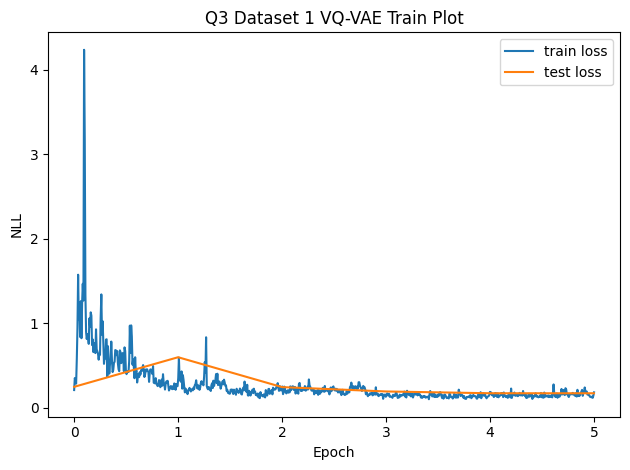

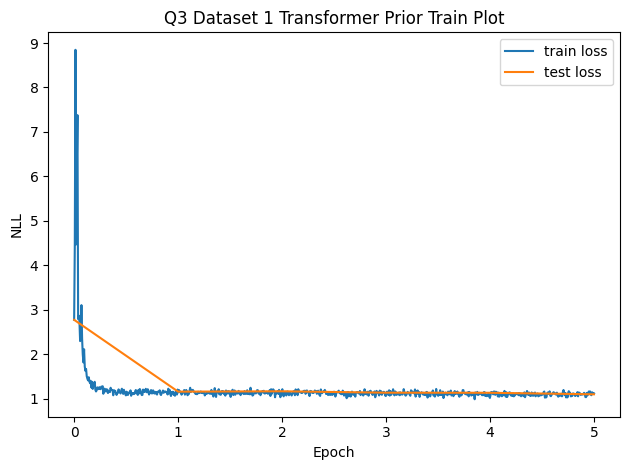

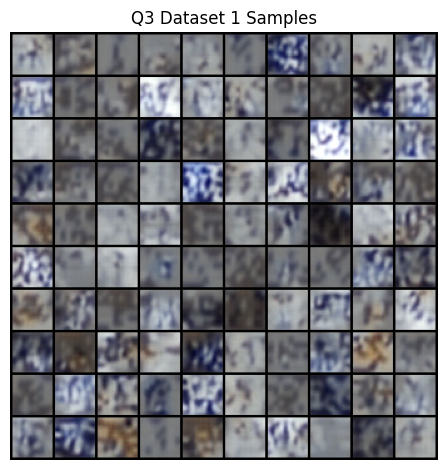

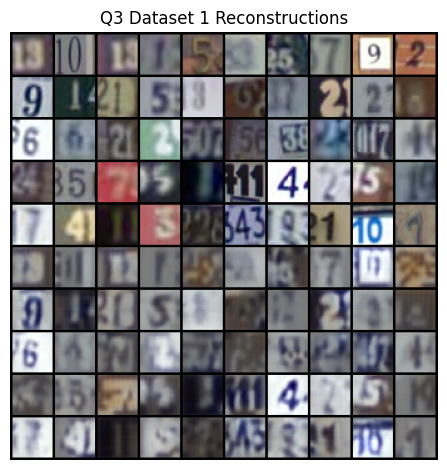

In [ ]:
q3_save_results(1, q3)

14320131


<ipython-input-5-c24330da4e3d>:155: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch, dtype=dtype).to(device)


0.2876231478657692


<ipython-input-5-c24330da4e3d>:170: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch, dtype=dtype).to(device)


0.17846903110006054
0.16454108363124215
0.13824275771903385
0.1376456356352302
0.12639684965656062
0.12100362165528498
0.10987408758158897
0.10558482036469088
0.10240749592424199
0.09494445022124394
0.09758254477552547
0.09485452313711688
0.09796693024172146
0.09310231718477929
0.09051393518212494
VAE done


...

5.209183477292395


<ipython-input-5-c24330da4e3d>:211: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  _, _, indices, z = model.get_indices(torch.tensor(x, dtype=dtype).to(device))
<ipython-input-5-c24330da4e3d>:214: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(indices, dtype=int).to(device)


2.1411715237198363
2.0748215405045043
2.0486907518593367
2.0319546514255986
2.0246290127942514
2.0271509544105286
2.0173323480946244
2.0139537533377387
2.0166944948730956
2.0136180220136217
2.015686390506234
2.015085093534676
2.0177794064685797
2.0221641724276695
2.0281892688411056


<ipython-input-5-c24330da4e3d>:134: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch[:n_samples], dtype=dtype).to(device)


VQ-VAE Final Test Loss: 0.0905
Transformer Prior Final Test Loss: 2.0282


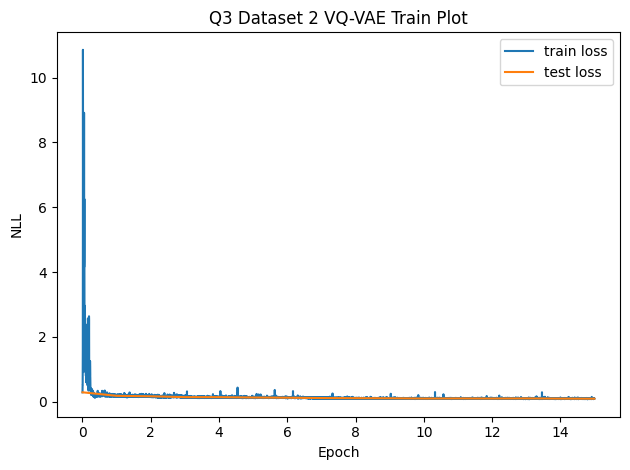

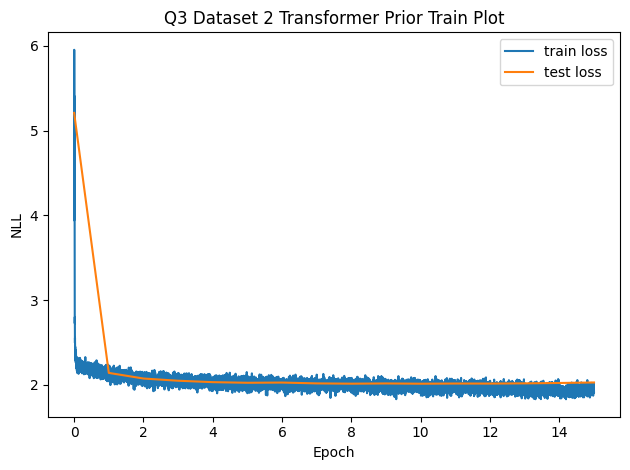

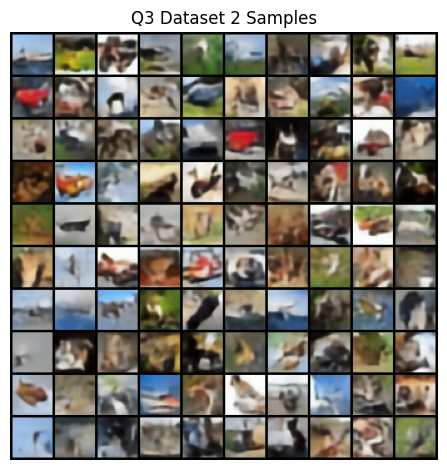

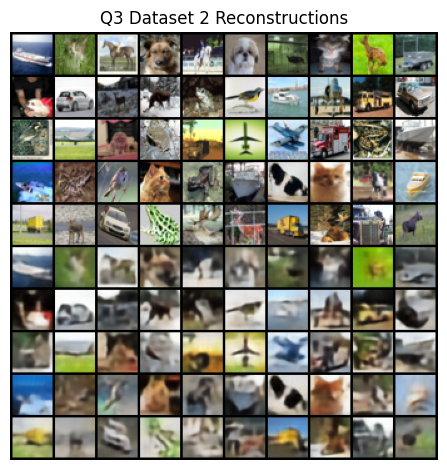

In [ ]:
q3_save_results(2, q3)

# File Saving Utility


In [ ]:
# one way to save files
from google.colab import files
import os
import os.path as osp
for fname in os.listdir('results'):
    files.download('results/' + fname)